In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
# import matplotlib
# matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
from astropy.table import Table, vstack, hstack, join
import fitsio
# from astropy.io import fits

In [2]:
params = {'legend.fontsize': 'x-large',
          'axes.labelsize': 'x-large',
          'axes.titlesize': 'x-large',
          'xtick.labelsize': 'x-large',
          'ytick.labelsize': 'x-large',
          'figure.facecolor': 'w',
          'xtick.top': True,
          'ytick.right': True,
          'xtick.direction': 'in',
          'ytick.direction': 'in',
         }
plt.rcParams.update(params)

In [3]:
cat = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_data/lrg_paper/lrg_extended_20211122_south.fits'))
print(len(cat))

mask = (cat['NOBS_G']>=2) & (cat['NOBS_R']>=2) & (cat['NOBS_Z']>=2)
cat = cat[mask]
print(len(cat))

maskbits = [1, 8, 9, 11, 12, 13]
mask_clean = np.ones(len(cat), dtype=bool)
for bit in maskbits:
    mask_clean &= (cat['MASKBITS'] & 2**bit)==0
print('{:} ({:.1f}%) objects removed by maskbits'.format(np.sum(~mask_clean), np.sum(~mask_clean)/len(mask_clean)*100))
cat = cat[mask_clean]
print(len(cat))

# Remove unmasked contaminated region
ramin, ramax, decmin, decmax = 151, 153, 12, 12.5
mask = (cat['RA']>ramin) & (cat['RA']<ramax) & (cat['DEC']>decmin) & (cat['DEC']<decmax)
cat = cat[~mask]
print(len(cat))

# Basic quality cuts
mask = (cat['FLUX_R']>0) & (cat['FLUX_IVAR_R']>0)
mask &= (cat['FLUX_Z']>0) & (cat['FLUX_IVAR_Z']>0)
mask &= (cat['FLUX_W1']>0) & (cat['FLUX_IVAR_W1']>0)
print(np.sum(~mask)/len(mask), np.sum(~mask))
cat = cat[mask]
print(len(cat))

# Remove objects with invalid photo-z's
mask = cat['Z_PHOT_MEDIAN']!=-99
print(np.sum(~mask)/len(mask), np.sum(~mask))
cat = cat[mask]

# Replace negative fluxes by 1e-7 (40 mag)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    gmag = 22.5 - 2.5*np.log10(np.clip(cat['FLUX_G']/cat['MW_TRANSMISSION_G'], 1e-7, None))
    rmag = 22.5 - 2.5*np.log10(np.clip(cat['FLUX_R']/cat['MW_TRANSMISSION_R'], 1e-7, None))
    zmag = 22.5 - 2.5*np.log10(np.clip(cat['FLUX_Z']/cat['MW_TRANSMISSION_Z'], 1e-7, None))
    w1mag = 22.5 - 2.5*np.log10(np.clip(cat['FLUX_W1']/cat['MW_TRANSMISSION_W1'], 1e-7, None))
    w2mag = 22.5 - 2.5*np.log10(np.clip(cat['FLUX_W2']/cat['MW_TRANSMISSION_W2'], 1e-7, None))
    zfibermag = 22.5 - 2.5*np.log10(np.clip(cat['FIBERFLUX_Z']/cat['MW_TRANSMISSION_Z'], 1e-7, None))
    
z_phot = cat['Z_PHOT_MEDIAN']

1261377
1261377
84617 (6.7%) objects removed by maskbits
1176760
1175942
4.336948591001937e-05 51
1175891
5.102513753400613e-06 6


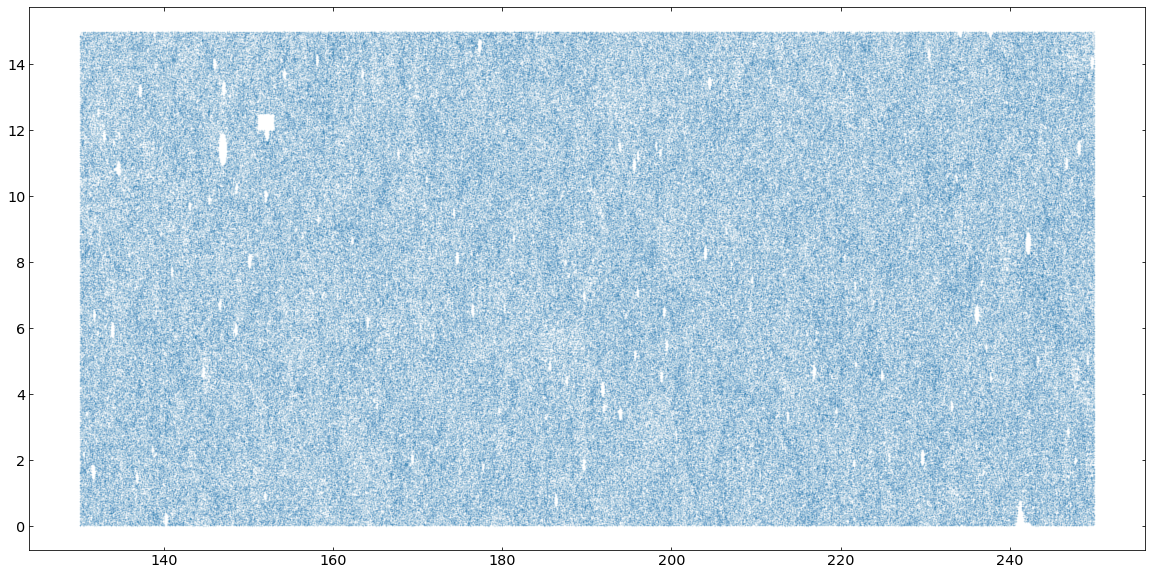

In [4]:
plt.figure(figsize=(20, 10))
plt.plot(cat['RA'], cat['DEC'], '.', ms=1, alpha=0.1)
plt.show()

In [5]:
# Load stars from a sweep catalog
sweep_path = '/Users/rongpu/Documents/Data/dr9/dr9.0/temp/sweep-120p010-130p015.fits'
cat_psf = Table(fitsio.read(sweep_path, columns=['TYPE','NOBS_G', 'NOBS_R', 'NOBS_Z', 'FLUX_Z', 'FIBERFLUX_Z', 'FLUX_IVAR_Z', 'MW_TRANSMISSION_Z']))
print(len(cat_psf))
cat_psf['zmag'] = 22.5 - 2.5*np.log10(np.clip(cat_psf['FLUX_Z']/cat_psf['MW_TRANSMISSION_Z'], 1e-7, None))
cat_psf['zfibermag'] = 22.5 - 2.5*np.log10(np.clip(cat_psf['FIBERFLUX_Z']/cat_psf['MW_TRANSMISSION_Z'], 1e-7, None))

mask = cat_psf['TYPE']=='PSF'
mask &= (cat_psf['NOBS_G']>=2) & (cat_psf['NOBS_R']>=2) & (cat_psf['NOBS_Z']>=2)
mask &= (cat_psf['FLUX_Z']>0) & (cat_psf['FLUX_IVAR_Z']>0)
############################################
mask &= (cat_psf['zmag']<20.5)
############################################
idx = np.where(mask)[0]
print(len(idx))

cat_psf = Table(fitsio.read(sweep_path, rows=idx))

# Replace negative fluxes by 1e-7 (40 mag)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    gmag_psf = 22.5 - 2.5*np.log10(np.clip(cat_psf['FLUX_G']/cat_psf['MW_TRANSMISSION_G'], 1e-7, None))
    rmag_psf = 22.5 - 2.5*np.log10(np.clip(cat_psf['FLUX_R']/cat_psf['MW_TRANSMISSION_R'], 1e-7, None))
    zmag_psf = 22.5 - 2.5*np.log10(np.clip(cat_psf['FLUX_Z']/cat_psf['MW_TRANSMISSION_Z'], 1e-7, None))
    w1mag_psf = 22.5 - 2.5*np.log10(np.clip(cat_psf['FLUX_W1']/cat_psf['MW_TRANSMISSION_W1'], 1e-7, None))
    w2mag_psf = 22.5 - 2.5*np.log10(np.clip(cat_psf['FLUX_W2']/cat_psf['MW_TRANSMISSION_W2'], 1e-7, None))
    zfibermag_psf = 22.5 - 2.5*np.log10(np.clip(cat_psf['FIBERFLUX_Z']/cat_psf['MW_TRANSMISSION_Z'], 1e-7, None))

4390932
463362


In [6]:
main_params = {
    'zfiber_max':21.6,
    'ns_a':0.8, 'ns_b':-0.6,
    'lowz_gw1':2.9, 'lowz_rw1':1.8,
    'ir_slope1':1.8, 'ir_slope2':1.,
    'ir_inter1':-17.14,  'ir_inter2':-16.33, 
    'rw1_highz':3.3,
}

sv3_params = {
    'zfiber_max':21.7,
    'ns_a':0.8, 'ns_b':-0.6,
    'lowz_a':-1.55, 'lowz_b':3.13,
    'lowz_gr':1.3, 'lowz_rw1':1.8,
    'ir_slope1':1.8, 'ir_slope2':1.,
    'ir_inter1':-17.26,  'ir_inter2':-16.36, 
    'rw1_highz':3.29,
}

sv_params = {
    'zfiber_max':22.0,
    'z_max':21.0,
    'ns_a':0.8, 'ns_b':-0.8,
    'rw1_min':1.0,
    'ir_slope':1.8, 'ir_inter':-17.48,
    'rw1_highz':3.1,
}

#   ((z < 20.2) AND (r - z > (z - 17.20) * 0.45) AND (r - z > (z - 14.17) * 0.19))
# -> ((z < a1)  AND (r - z > (z - a2) * a3)      AND (r - z > (z - a4) * a5))
#    ((z >= 20.2) AND (((z - 23.18) / 1.3)^2 + (r - z + 2.5)^2 > 4.48^2))
# -> ((z >= a1) AND   (((z - a6) / a7)^2 +     (r - z + a8)^2 > a9^2))
sv_params_more = {
    'a1':20.2,
    'a2':17.20,
    'a3':0.45,
    'a4':14.17,
    'a5':0.19,
    'a6':23.18,
    'a7':1.3,
    'a8':2.5,
    'a9':4.48,
}

--------
# Main selection

1.8225000000000025 18.1525


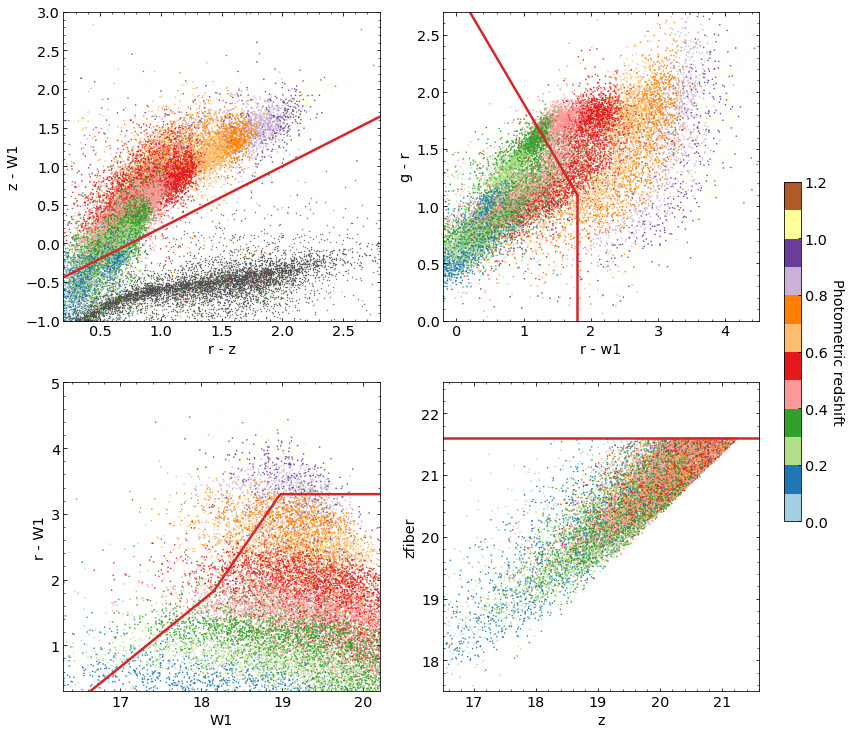

In [7]:
# All galaxies

np.random.seed(342)
idx_psf = np.random.choice(len(cat_psf), size=10000, replace=False)
mask = (zfibermag<21.6) & (cat['TYPE']!='PSF')
idx_all = np.random.choice(np.where(mask)[0], size=20000, replace=False)

fig, axes = plt.subplots(2, 2, figsize=(15.2, 12.5))

################# non-stellar cut #################
ax = axes[0, 0]
ax.scatter((rmag_psf-zmag_psf)[idx_psf], (zmag_psf-w1mag_psf)[idx_psf], 
            c='0.3', s=0.15, vmin=0., vmax=1.2)
im = ax.scatter((rmag-zmag)[idx_all], (zmag-w1mag)[idx_all], 
            c=z_phot[idx_all], s=0.3, cmap='Paired', vmin=0., vmax=1.2)
ax.set_xlabel('r - z')
ax.set_ylabel('z - W1')
ax.axis([0.2, 2.8, -1, 3])

# Lines -- SV3 and final
x = np.linspace(0, 3)
y = main_params['ns_a'] * x + main_params['ns_b']
ax.plot(x, y, 'C3', lw=2.5)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())

################# g-r vs r-W1 #################
ax = axes[0, 1]
im = ax.scatter((rmag-w1mag)[idx_all], (gmag-rmag)[idx_all], 
         c=z_phot[idx_all], s=0.3, cmap='Paired', vmin=0., vmax=1.2)
ax.set_xlabel('r - w1')
ax.set_ylabel('g - r')
ax.axis([-0.2, 4.5, 0, 2.7])

# Lines -- final
x1 = np.linspace(-2, main_params['lowz_rw1'], 1000)
y1 = -x1 + main_params['lowz_gw1']
ax.plot(x1, y1, 'C3', lw=2.5)
y2 = np.linspace(-5, y1.min())
x2 = main_params['lowz_rw1'] * np.ones_like(y2)
ax.plot(x2, y2, 'C3', lw=2.5)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())

################# IR sliding cut #################
ax = axes[1, 0]
im = ax.scatter((w1mag)[idx_all], (rmag-w1mag)[idx_all], 
         c=z_phot[idx_all], s=0.3, cmap='Paired', vmin=0., vmax=1.2)
ax.set_xlabel('W1')
ax.set_ylabel('r - W1')
ax.axis([16.3, 20.2, 0.3, 5.])

a1, b1, a2, b2 = main_params['ir_slope1'], main_params['ir_slope1']*main_params['ir_inter1'], main_params['ir_slope2'], main_params['ir_slope2']*main_params['ir_inter2']
yc = (a2*b1-a1*b2)/(a2-a1)
xc = (yc-b1)/a1
print(yc, xc)

# Lines -- final
x = np.linspace(xc, 23, 200)
y = np.zeros(len(x))
y = (x + main_params['ir_inter1']) * main_params['ir_slope1']
mask = (y>main_params['rw1_highz'])
y[mask] = main_params['rw1_highz']
ax.plot(x, y, 'C3', lw=2.5)
x = np.linspace(15, xc, 200)
y = np.zeros(len(x))
y = (x + main_params['ir_inter2']) * main_params['ir_slope2']
ax.plot(x, y, 'C3', lw=2.5)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())

################# zfiber vs z #################
ax = axes[1, 1]
im = ax.scatter((zmag)[idx_all], (zfibermag)[idx_all], 
         c=z_phot[idx_all], s=0.3, cmap='Paired', vmin=0., vmax=1.2)
ax.set_xlabel('z')
ax.set_ylabel('zfiber')
ax.axis([16.5, 21.6, 17.5, 22.5])

# Lines -- final
x = np.linspace(0, 100)
y = main_params['zfiber_max'] * np.ones_like(x)
ax.plot(x, y, 'C3', lw=2.5)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())

cb = fig.colorbar(im, ax=axes, location='right', shrink=0.5, pad=0.03)
cb.ax.get_yaxis().labelpad = 16
cb.ax.set_ylabel('Photometric redshift', rotation=270)

# plt.tight_layout()
plt.savefig('/Users/rongpu/git/desi-targets/lrg_paper/figures/main_lrg_selection.png', dpi=110)
plt.show()

--------
# Add SV1 and SV3 selections

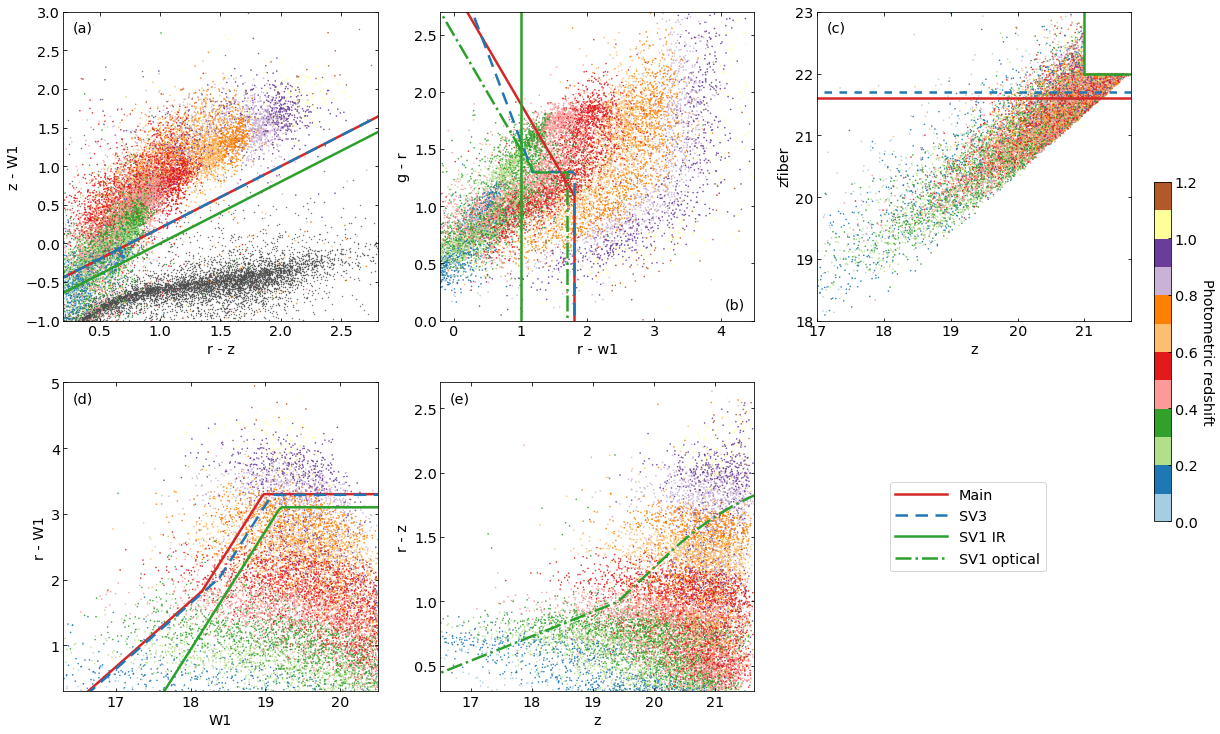

In [8]:
# All galaxies

np.random.seed(342)
idx_psf = np.random.choice(len(cat_psf), size=10000, replace=False)
mask = ((zfibermag<22.0) | (zmag<21.0)) & (cat['TYPE']!='PSF')
idx_all = np.random.choice(np.where(mask)[0], size=15000, replace=False)

fig, axes = plt.subplots(2, 3, figsize=(23., 12.5))

################# non-stellar cut #################
ax = axes[0, 0]
ax.scatter((rmag_psf-zmag_psf)[idx_psf], (zmag_psf-w1mag_psf)[idx_psf], 
            c='0.3', s=0.15, vmin=0., vmax=1.2)
im = ax.scatter((rmag-zmag)[idx_all], (zmag-w1mag)[idx_all], 
            c=z_phot[idx_all], s=0.3, cmap='Paired', vmin=0., vmax=1.2)
ax.set_xlabel('r - z')
ax.set_ylabel('z - W1')
ax.axis([0.2, 2.8, -1, 3])

# Lines -- SV3 and final
x = np.linspace(0, 3)
y = sv3_params['ns_a'] * x + sv3_params['ns_b']
ax.plot(x, y, 'C3', lw=2.5)
ax.plot(x, y, 'C0', lw=2.5, ls='--', dashes=(5, 3))

# Lines -- SV
x = np.linspace(0, 3)
y = sv_params['ns_a'] * x + sv_params['ns_b']
ax.plot(x, y, 'C2', lw=2.5)

ax.text(0.03, 0.97, '(a)', ha='left', va='top', transform=ax.transAxes, fontsize='x-large')

################# g-r vs r-W1 #################
ax = axes[0, 1]
im = ax.scatter((rmag-w1mag)[idx_all], (gmag-rmag)[idx_all], 
         c=z_phot[idx_all], s=0.3, cmap='Paired', vmin=0., vmax=1.2)
ax.set_xlabel('r - w1')
ax.set_ylabel('g - r')
ax.axis([-0.2, 4.5, 0, 2.7])

# Lines -- final
x1 = np.linspace(-2, main_params['lowz_rw1'], 1000)
y1 = -x1 + main_params['lowz_gw1']
ax.plot(x1, y1, 'C3', lw=2.5)
y2 = np.linspace(-5, y1.min())
x2 = main_params['lowz_rw1'] * np.ones_like(y2)
ax.plot(x2, y2, 'C3', lw=2.5, label='Main')

# Lines -- SV3
x1 = np.linspace(-2, sv3_params['lowz_rw1'], 1000)
y1 = sv3_params['lowz_a'] * x1 + sv3_params['lowz_b']
y1[y1<=1.3] = sv3_params['lowz_gr']
ax.plot(x1, y1, 'C0', lw=2.5, ls='--', dashes=(5, 3), label='SV3')
y2 = np.linspace(-5, 1.3)
x2 = sv3_params['lowz_rw1'] * np.ones_like(y2)
ax.plot(x2, y2, 'C0', lw=2.5, ls='--', dashes=(5, 3))

# Lines -- SV IR
y1 = np.linspace(-5, 5)
x1 = sv_params['rw1_min'] * np.ones_like(y1)
ax.plot(x1, y1, 'C2', lw=2.5, label='SV1 IR')

# Lines -- SV optical
x1 = np.linspace(-5, 1.2)
y1 = 2.5 - x1
x2 = np.linspace(1.2, 1.7)
y2 = 1.3 * np.ones_like(x1)
y3 = np.linspace(-5, 1.3)
x3 = 1.7 * np.ones_like(y3)
ax.plot(x1, y1, 'C2-.', lw=2.5, label='SV1 optical')
ax.plot(x2, y2, 'C2-.', lw=2.5)
ax.plot(x3, y3, 'C2-.', lw=2.5)

ax.text(0.97, 0.03, '(b)', ha='right', va='bottom', transform=ax.transAxes, fontsize='x-large')

ax.legend(bbox_to_anchor=(1.95, -0.5), handlelength=3.6)

################# zfiber vs z #################
ax = axes[0, 2]
im = ax.scatter((zmag)[idx_all], (zfibermag)[idx_all], 
         c=z_phot[idx_all], s=0.3, cmap='Paired', vmin=0., vmax=1.2)
ax.set_xlabel('z')
ax.set_ylabel('zfiber')
ax.axis([17., 21.7, 18., 23])

# Lines -- final
x = np.linspace(0, 100)
y = main_params['zfiber_max'] * np.ones_like(x)
ax.plot(x, y, 'C3', lw=2.5)

# Lines -- SV3
x = np.linspace(0, 100)
y = sv3_params['zfiber_max'] * np.ones_like(x)
ax.plot(x, y, 'C0', lw=2.5, ls='--', dashes=(3, 3))

# Lines -- SV
x1 = np.linspace(sv_params['z_max'], 100)
y1 = sv_params['zfiber_max'] * np.ones_like(x)
x2 = np.ones(20) * sv_params['z_max']
y2 = np.linspace(sv_params['zfiber_max'], 100, len(x2))
ax.plot(x1, y1, 'C2', lw=2.5)
ax.plot(x2, y2, 'C2', lw=2.5)

ax.text(0.03, 0.97, '(c)', ha='left', va='top', transform=ax.transAxes, fontsize='x-large')

################# IR sliding cut #################
ax = axes[1, 0]
im = ax.scatter((w1mag)[idx_all], (rmag-w1mag)[idx_all], 
         c=z_phot[idx_all], s=0.3, cmap='Paired', vmin=0., vmax=1.2)
ax.set_xlabel('W1')
ax.set_ylabel('r - W1')
ax.axis([16.3, 20.5, 0.3, 5.])

# Lines -- final
a1, b1, a2, b2 = main_params['ir_slope1'], main_params['ir_slope1']*main_params['ir_inter1'], main_params['ir_slope2'], main_params['ir_slope2']*main_params['ir_inter2']
yc = (a2*b1-a1*b2)/(a2-a1)
xc = (yc-b1)/a1
# print(yc, xc)
x = np.linspace(xc, 23, 200)
y = np.zeros(len(x))
y = (x + main_params['ir_inter1']) * main_params['ir_slope1']
mask = (y>main_params['rw1_highz'])
y[mask] = main_params['rw1_highz']
ax.plot(x, y, 'C3', lw=2.5)
x = np.linspace(15, xc, 200)
y = np.zeros(len(x))
y = (x + main_params['ir_inter2']) * main_params['ir_slope2']
ax.plot(x, y, 'C3', lw=2.5)

# Lines -- SV3
a1, b1, a2, b2 = sv3_params['ir_slope1'], sv3_params['ir_slope1']*sv3_params['ir_inter1'], sv3_params['ir_slope2'], sv3_params['ir_slope2']*sv3_params['ir_inter2']
yc3 = (a2*b1-a1*b2)/(a2-a1)
xc3 = (yc3-b1)/a1
x = np.linspace(xc3, 23, 200)
y = np.zeros(len(x))
y = (x + sv3_params['ir_inter1']) * sv3_params['ir_slope1']
mask = (y>sv3_params['rw1_highz'])
y[mask] = sv3_params['rw1_highz']
ax.plot(x, y, 'C0', lw=2.5, ls='--', dashes=(5, 3))
x = np.linspace(15, xc3, 200)
y = np.zeros(len(x))
y = (x + sv3_params['ir_inter2']) * sv3_params['ir_slope2']
ax.plot(x, y, 'C0', lw=2.5, ls='--', dashes=(5, 3))

# Lines -- SV
x = np.linspace(15, 23, 200)
y = np.zeros(len(x))
y = (x + sv_params['ir_inter']) * sv_params['ir_slope']
mask = y>sv_params['rw1_highz']
y[mask] = sv_params['rw1_highz']
ax.plot(x, y, 'C2', lw=2.5)

ax.text(0.03, 0.97, '(d)', ha='left', va='top', transform=ax.transAxes, fontsize='x-large')

################# optical sliding cut #################
ax = axes[1, 1]
im = ax.scatter((zmag)[idx_all], (rmag-zmag)[idx_all], 
         c=z_phot[idx_all], s=0.3, cmap='Paired', vmin=0., vmax=1.2)
ax.set_xlabel('z')
ax.set_ylabel('r - z')
ax.axis([16.5, 21.65, 0.3, 2.7])

# Lines -- SV
x = np.linspace(15, 23, 200)
y = np.zeros(len(x))
mask = (x<19.46)
y[mask] = (x[mask] - sv_params_more['a4']) * sv_params_more['a5']
mask = (x>=19.46) & (x<sv_params_more['a1'])
y[mask] = (x[mask] - sv_params_more['a2']) * sv_params_more['a3']
mask = (x>=sv_params_more['a1'])
y[mask] = np.sqrt(sv_params_more['a9']**2-((x[mask]-sv_params_more['a6'])/sv_params_more['a7'])**2) - sv_params_more['a8']
ax.plot(x, y, 'C2-.', lw=2.5)
# ax.legend(loc='upper left', handlelength=2.8)

ax.text(0.03, 0.97, '(e)', ha='left', va='top', transform=ax.transAxes, fontsize='x-large')

######################################################

axes[1,2].set_visible(False)

cb = fig.colorbar(im, ax=axes, location='right', shrink=0.5, pad=0.018)
cb.ax.get_yaxis().labelpad = 16
cb.ax.set_ylabel('Photometric redshift', rotation=270)

# plt.tight_layout()

plt.savefig('/Users/rongpu/git/desi-targets/lrg_paper/figures/all_lrg_selections.png', dpi=110)
plt.show()

################################################################################################

fits = fitsio.FITS('zenodo/fig_15.fits','rw')

t = Table()
t['gmag'] = gmag[idx_all]
t['rmag'] = rmag[idx_all]
t['zmag'] = zmag[idx_all]
t['zfibermag'] = zfibermag[idx_all]
t['w1mag'] = w1mag[idx_all]
t['redshift_bin'] = (np.floor(z_phot[idx_all]*10)+0.5)/10
fits.write(dict(t), extname='lrgs')

t = Table()
t['gmag'] = gmag_psf[idx_psf]
t['rmag'] = rmag_psf[idx_psf]
t['zmag'] = zmag_psf[idx_psf]
t['w1mag'] = w1mag_psf[idx_psf]
fits.write(dict(t), extname='stars')

fits.close()

In [9]:
fitsio.FITS('zenodo/fig_15.fits')


  file: zenodo/fig_15.fits
  mode: READONLY
  extnum hdutype         hduname[v]
  0      IMAGE_HDU       
  1      BINARY_TBL      lrgs
  2      BINARY_TBL      stars